In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, RocCurveDisplay
import matplotlib.pyplot as plt


In [2]:

file_path = "BRFSS_2024_combined.parquet"

df24 = pd.read_parquet(file_path, engine="pyarrow")

print("Shape:", df24.shape)
print("Columns:", df24.columns.tolist())
df24.head()

Shape: (457670, 301)
Columns: ['_STATE', 'FMONTH', 'IDATE', 'IMONTH', 'IDAY', 'IYEAR', 'DISPCODE', 'SEQNO', '_PSU', 'CTELENM1', 'PVTRESD1', 'COLGHOUS', 'STATERE1', 'CELPHON1', 'LADULT1', 'NUMADULT', 'RESPSLC1', 'LANDSEX3', 'SAFETIME', 'CTELNUM1', 'CELLFON5', 'CADULT1', 'CELLSEX3', 'PVTRESD3', 'CCLGHOUS', 'CSTATE1', 'LANDLINE', 'HHADULT', 'SEXVAR', 'GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'POORHLTH', 'PRIMINS2', 'PERSDOC3', 'MEDCOST1', 'CHECKUP1', 'EXERANY2', 'LASTDEN4', 'RMVTETH4', 'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3', 'ASTHMA3', 'ASTHNOW', 'CHCSCNC1', 'CHCOCNC1', 'CHCCOPD3', 'ADDEPEV3', 'CHCKDNY2', 'HAVARTH4', 'DIABETE4', 'DIABAGE4', 'MARITAL', 'EDUCA', 'RENTHOM1', 'NUMHHOL4', 'NUMPHON4', 'CPDEMO1C', 'VETERAN3', 'EMPLOY1', 'CHILDREN', 'INCOME3', 'PREGNANT', 'WEIGHT2', 'HEIGHT3', 'DEAF', 'BLIND', 'DECIDE', 'DIFFWALK', 'DIFFDRES', 'DIFFALON', 'HADMAM', 'HOWLONG', 'CERVSCRN', 'CRVCLCNC', 'CRVCLPAP', 'CRVCLHPV', 'HADHYST2', 'HADSIGM4', 'COLNSIGM', 'COLNTES1', 'SIGMTES1', 'LASTSIG4', 'COLNCNCR', '

,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENM1,...,_LCSCTSN,_LCSPSTF,DRNKANY6,DROCDY4_,_RFBING6,_DRNKWK3,_RFDRHV9,_FLSHOT7,_PNEUMO3,_AIDTST4
0,1.0,2.0,b'02282024',b'02',b'28',b'2024',1100.0,b'2024000001',2.024000e+09,1.0,...,NaN,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,2.0,2.0
1,1.0,2.0,b'02212024',b'02',b'21',b'2024',1100.0,b'2024000002',2.024000e+09,1.0,...,4.0,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,1.0,2.0
2,1.0,2.0,b'02212024',b'02',b'21',b'2024',1100.0,b'2024000003',2.024000e+09,1.0,...,4.0,2.0,1.0,1.000000e+02,2.0,1.400000e+03,1.0,NaN,NaN,2.0
3,1.0,2.0,b'02282024',b'02',b'28',b'2024',1100.0,b'2024000004',2.024000e+09,1.0,...,NaN,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,1.0,2.0
4,1.0,2.0,b'02212024',b'02',b'21',b'2024',1100.0,b'2024000005',2.024000e+09,1.0,...,3.0,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,NaN,NaN,2.0


In [3]:
features_24 = [
    "_ASTHMS1", "CHCKDNY2", "_DRDXAR2",
    "_EDUCAG", "_INCOMG1", "_AGE_G", "_SEX",
    "WTKG3", "HTM4", "_RFBMI5", "_BMI5",
    "_RFDRHV9", "_RFSMOK3", "_TOTINDA"
]
target = "DIABETE4"

df_model = df24[features_24 + [target]].copy()
df_model.head()

,_ASTHMS1,CHCKDNY2,_DRDXAR2,_EDUCAG,_INCOMG1,_AGE_G,_SEX,WTKG3,HTM4,_RFBMI5,_BMI5,_RFDRHV9,_RFSMOK3,_TOTINDA,DIABETE4
0,3.0,2.0,1.0,2.0,9.0,6.0,2.0,5942.0,163.0,1.0,2249.0,1.0,1.0,1.0,3.0
1,3.0,2.0,1.0,4.0,7.0,6.0,1.0,8165.0,178.0,2.0,2583.0,1.0,1.0,1.0,3.0
2,3.0,2.0,1.0,3.0,9.0,5.0,1.0,8845.0,198.0,1.0,2253.0,1.0,2.0,1.0,3.0
3,3.0,2.0,1.0,4.0,4.0,6.0,1.0,7484.0,173.0,2.0,2509.0,1.0,1.0,1.0,3.0
4,3.0,2.0,2.0,3.0,2.0,4.0,1.0,5897.0,173.0,1.0,1977.0,1.0,1.0,2.0,3.0


## Class

In [4]:
print("Class distribution:")
print(df_model[target].value_counts())


Class distribution:
DIABETE4
3.0    376125
1.0     65809
4.0     11307
2.0      3395
7.0       798
9.0       232
Name: count, dtype: int64


## Preprocessing

In [5]:
df_model = df_model[df_model[target].isin([1,3,4])].copy()

# Map 1=Diabetes, 4=Prediabetes to 1; 3= No to 0
df_model['DIABETE_BIN'] = df_model[target].replace({1:1, 4:1, 3:0})


### Categorical

In [6]:
binary_map = {"Yes":1, "No":0, "Y":1, "N":0, 1:1, 2:0}
binary_cols = ["_ASTHMS1", "CHCKDNY2", "_DRDXAR2", "_RFDRHV9", "_RFSMOK3"]

for col in binary_cols:
    df_model[col] = df_model[col].replace({1:1, 2:0, 7:np.nan, 9:np.nan})

 # 7 and 9 are unknown or refused

#Male=0, Female=1
df_model["_SEX"] = df_model["_SEX"].replace({1:0, 2:1})

In [7]:
print(df_model["CHCKDNY2"].unique())

[ 0.  1. nan]


### Nan

In [8]:
nan_counts = df_model[features_24].isna().sum()

print("Number of missing values per feature:")
print(nan_counts)

nan_percent = (df_model[features_24].isna().mean() * 100).round(2)
print("\nPercentage of missing values per feature:")
print(nan_percent)

Number of missing values per feature:
_ASTHMS1     3684
CHCKDNY2     1746
_DRDXAR2     2269
_EDUCAG         0
_INCOMG1        0
_AGE_G          0
_SEX            0
WTKG3       35799
HTM4        23597
_RFBMI5         0
_BMI5       42248
_RFDRHV9    46099
_RFSMOK3    31564
_TOTINDA        0
dtype: int64

Percentage of missing values per feature:
_ASTHMS1     0.81
CHCKDNY2     0.39
_DRDXAR2     0.50
_EDUCAG      0.00
_INCOMG1     0.00
_AGE_G       0.00
_SEX         0.00
WTKG3        7.90
HTM4         5.21
_RFBMI5      0.00
_BMI5        9.32
_RFDRHV9    10.17
_RFSMOK3     6.96
_TOTINDA     0.00
dtype: float64


In [9]:
from sklearn.impute import SimpleImputer

num_cols = ['WTKG3', 'HTM4', '_BMI5']
num_imputer = SimpleImputer(strategy='median')
df_model[num_cols] = num_imputer.fit_transform(df_model[num_cols])

bin_cols = ['_ASTHMS1', 'CHCKDNY2', '_DRDXAR2', '_RFDRHV9', '_RFSMOK3']
bin_imputer = SimpleImputer(strategy='most_frequent')
df_model[bin_cols] = bin_imputer.fit_transform(df_model[bin_cols])

In [10]:
nan_counts = df_model[features_24].isna().sum()

print("Number of missing values per feature:")
print(nan_counts)

nan_percent = (df_model[features_24].isna().mean() * 100).round(2)
print("\nPercentage of missing values per feature:")
print(nan_percent)

Number of missing values per feature:
_ASTHMS1    0
CHCKDNY2    0
_DRDXAR2    0
_EDUCAG     0
_INCOMG1    0
_AGE_G      0
_SEX        0
WTKG3       0
HTM4        0
_RFBMI5     0
_BMI5       0
_RFDRHV9    0
_RFSMOK3    0
_TOTINDA    0
dtype: int64

Percentage of missing values per feature:
_ASTHMS1    0.0
CHCKDNY2    0.0
_DRDXAR2    0.0
_EDUCAG     0.0
_INCOMG1    0.0
_AGE_G      0.0
_SEX        0.0
WTKG3       0.0
HTM4        0.0
_RFBMI5     0.0
_BMI5       0.0
_RFDRHV9    0.0
_RFSMOK3    0.0
_TOTINDA    0.0
dtype: float64


## Feature Engineeing

In [11]:
X = df_model[features_24]
y = df_model['DIABETE_BIN']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original feature count:", X_train.shape[1])
print("PCA reduced feature count:", X_train_pca.shape[1])



Original feature count: 14
PCA reduced feature count: 12


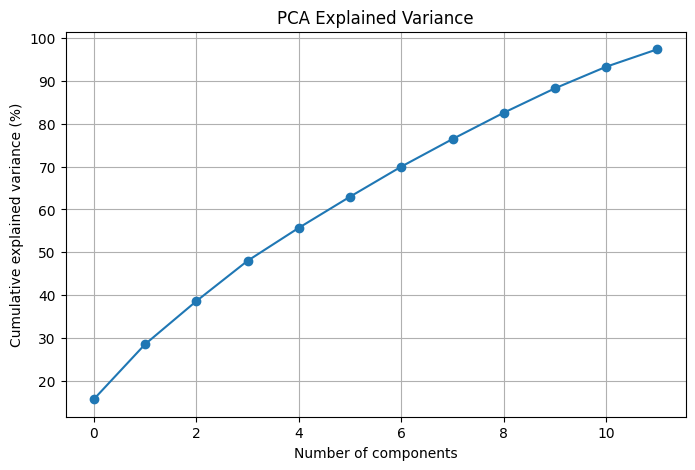

In [12]:
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_)*100, marker='o')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance (%)')
plt.title('PCA Explained Variance')
plt.grid(True)
plt.show()

In [14]:
n_comp = pca.components_.shape[0]
loadings = pd.DataFrame(pca.components_.T,
                        columns=[f'PC{i+1}' for i in range(n_comp)],
                        index=features_24)

top5_PC1 = loadings['PC1'].abs().sort_values(ascending=False).head(5)
top5_PC2 = loadings['PC2'].abs().sort_values(ascending=False).head(5)

print("Top 5 features for PC1:")
print(top5_PC1)

print("\nTop 5 features for PC2:")
print(top5_PC2)

Top 5 features for PC1:
WTKG3     0.613656
HTM4      0.479624
_SEX      0.449354
_BMI5     0.425211
_AGE_G    0.091231
Name: PC1, dtype: float64

Top 5 features for PC2:
_DRDXAR2    0.446704
_BMI5       0.425974
_AGE_G      0.334611
HTM4        0.315994
_SEX        0.296839
Name: PC2, dtype: float64


- PC1 = Physical profile / body size
- PC2 = Health status / chronic disease variance


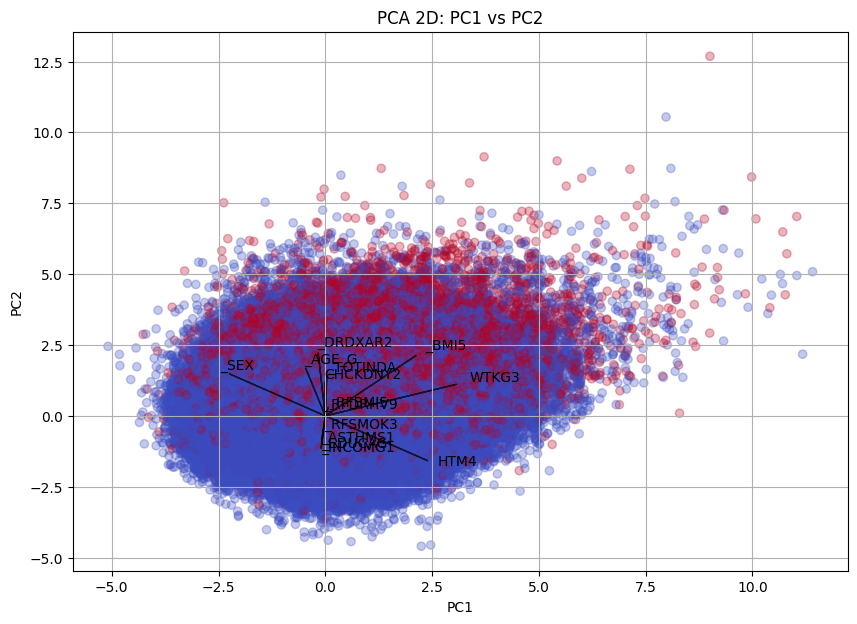

In [17]:

X_pca_2d = X_train_pca[:, :2]

plt.figure(figsize=(10,7))
plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1], c=y_train, cmap='coolwarm', alpha=0.3)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA 2D: PC1 vs PC2')

loadings = pca.components_[:2, :].T

scaling_factor = 5
for i, feature in enumerate(features_24):
    plt.arrow(0, 0, loadings[i,0]*scaling_factor, loadings[i,1]*scaling_factor, color='black', alpha=0.7)
    plt.text(loadings[i,0]*scaling_factor*1.1, loadings[i,1]*scaling_factor*1.1, feature, fontsize=10)

plt.grid(True)
plt.show()

In [23]:
print(y.value_counts())

DIABETE_BIN
0.0    376125
1.0     77116
Name: count, dtype: int64


## Model

              precision    recall  f1-score   support

         0.0       0.85      0.94      0.89     75226
         1.0       0.39      0.20      0.26     15423

    accuracy                           0.81     90649
   macro avg       0.62      0.57      0.58     90649
weighted avg       0.77      0.81      0.78     90649



<Figure size 1000x600 with 0 Axes>

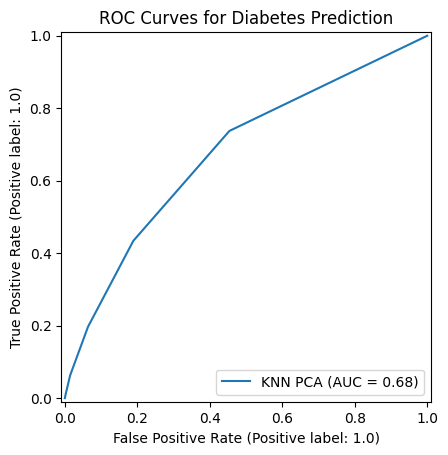

In [19]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_pca, y_train)
y_pred_knn = knn.predict(X_test_pca)

print(classification_report(y_test, y_pred_knn))

plt.figure(figsize=(10,6))
RocCurveDisplay.from_estimator(knn, X_test_pca, y_test, name="KNN PCA")
plt.title("ROC Curves for Diabetes Prediction")
plt.show()


- F1 macro 58% (reflecting the **average performance across both classes equally**, without weighting by their frequency.
)